# Estatísticas para o artigo (sMCI × pMCI)

Notebook de **testes pareados** sobre scores por paciente (`ablation_results_all.csv` e variantes). Config em `STATS_CFG` (default: `smci_pmci`, `vol`, `svm`, `abs`, `l1_stable`, `combat=False`).

---

## Roteiro

| # | Pergunta | Saída |
|---|----------|-------|
| **1** | Grupos têm **idade/sexo** diferentes? | Mann-Whitney / χ² |
| **2** | **Idade** ou **sexo** sozinhos separam classes? | AUC + permutação |
| **3** | **Imagem** vai além da demografia? | ΔAUC bootstrap |
| **4** | **abs** (wide) > **t1_only**? | ΔAUC pareado + **FDR** (5 modalidades) |
| **5** | **abs** (leak-free) vs **global** (leaky)? | Impacto do vazamento |
| **6** | **Clínico** vs **imagem** vs **fusão**? | Valor incremental da RM |
| **7** | Quais **atributos** o modelo seleciona? | Frequência estável (stable pool) |
| **8** | Exportar CSVs para o paper | `csvs/longitudinal_4_groups/stats_*.csv` |

---

## Glossário

| Termo | Leitura |
|-------|---------|
| **ΔAUC** | AUC(A) − AUC(B) nos mesmos pacientes |
| **IC95%** | Intervalo bootstrap do ΔAUC |
| **p (one-sided)** | H₀: ΔAUC ≤ 0 — A melhor que B? |
| **q (FDR-BH)** | p ajustado para 5 modalidades na mesma comparação |
| **significant_fdr** | q < 0,05 **e** IC95% não cruza zero |

> Comparações usam **mesmo** `model_key`, `selection_mode` e `with_combat` em `STATS_CFG`. Ajuste antes de rodar se o melhor modelo for `elasticnet`.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.metrics import roc_auc_score

from ablation_analysis import (
    explode_patient_predictions,
    feature_freq_table,
    feature_freq_table_grouped,
    prepare_ablation_df,
)
from stats_compare import (
    apply_bh_fdr,
    clinical_results_path,
    compare_modalities,
    fusion_results_path,
    image_ablation_path,
    paired_comparison_row,
    print_comparison_summary,
)

BASE = Path("csvs/longitudinal_4_groups")
LONG_CSV = BASE / "ablation" / "hippocampus" / "vol_long.csv"
MODS_COMPARE = ("vol", "shape", "texture", "disp", "all")
FEATURE_MIN_COVERAGE = 50  # % folds com atributo (paper: top estáveis)


@dataclass(frozen=True)
class StatsCfg:
    task: str = "smci_pmci"
    groups: tuple[str, str] = ("sMCI", "pMCI")
    positive_group: str = "pMCI"
    modality: str = "vol"
    model_key: str = "svm"
    with_combat: bool = False
    selection_mode: str = "l1_stable"
    protocol: str = "abs"
    n_perm: int = 5000
    n_bootstrap: int = 5000
    seed: int = 42


ALPHA = 0.05  # limiar usual em artigos (5%)


def ler_p(p: float, *, contexto: str = "") -> str:
    """Texto curto para interpretar um p-value."""
    tag = "significativo" if p < ALPHA else "não significativo"
    acaso = "rejeitamos hipótese nula" if p < ALPHA else "compatível com acaso"
    prefix = f"{contexto}: " if contexto else ""
    return f"{prefix}{tag} (p={p:.4f}) — {acaso}"


STATS_CFG = StatsCfg()
print("Configuração atual:")
print(f"  task={STATS_CFG.task}  grupos={STATS_CFG.groups}")
print(f"  imagem: protocolo={STATS_CFG.protocol}  modality={STATS_CFG.modality}  model={STATS_CFG.model_key}")
print(f"  permutações={STATS_CFG.n_perm}  bootstrap={STATS_CFG.n_bootstrap}")


Configuração atual:
  task=smci_pmci  grupos=('sMCI', 'pMCI')
  imagem: protocolo=abs  modality=vol  model=svm
  permutações=5000  bootstrap=5000


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def load_cohort(long_path: Path, cfg: StatsCfg) -> pd.DataFrame:
    sub = pd.read_csv(long_path)
    sub = sub[sub["slot"].astype(str) == "baseline"]
    sub = sub.sort_values(["ID_PT", "ID_IMG"]).groupby("ID_PT", as_index=False).first()
    sub = sub[sub["GROUP"].isin(cfg.groups)].copy()
    sub["ID_PT"] = sub["ID_PT"].astype(str)
    sub["y"] = (sub["GROUP"] == cfg.positive_group).astype(int)
    sub["SEX_bin"] = sub["SEX"].map({"M": 0, "F": 1, 0: 0, 1: 1})
    return sub


def permutation_auc_p(
    y: np.ndarray,
    scores: np.ndarray,
    *,
    n_perm: int,
    seed: int,
    bidirectional: bool = False,
) -> tuple[float, float]:
    y = np.asarray(y, dtype=int)
    s = np.asarray(scores, dtype=float)
    if bidirectional:
        auc_obs = float(max(roc_auc_score(y, s), roc_auc_score(y, -s)))
    else:
        auc_obs = float(roc_auc_score(y, s))
    prng = np.random.default_rng(seed)
    ge = 0
    for _ in range(n_perm):
        yp = prng.permutation(y)
        auc_n = max(roc_auc_score(yp, s), roc_auc_score(yp, -s)) if bidirectional else roc_auc_score(yp, s)
        ge += int(auc_n >= auc_obs)
    return auc_obs, (ge + 1) / (n_perm + 1)


def bootstrap_auc_diff(y, scores_a, scores_b, *, n_boot: int, seed: int) -> tuple[float, float, float]:
    y = np.asarray(y, dtype=int)
    a, b = np.asarray(scores_a, float), np.asarray(scores_b, float)
    obs = float(roc_auc_score(y, a) - roc_auc_score(y, b))
    prng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        idx = prng.integers(0, len(y), size=len(y))
        yb, ab, bb = y[idx], a[idx], b[idx]
        if len(np.unique(yb)) < 2:
            continue
        diffs.append(float(roc_auc_score(yb, ab) - roc_auc_score(yb, bb)))
    diffs = np.asarray(diffs)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    return obs, float(ci_lo), float(ci_hi)


def bootstrap_auc_diff_test(
    y,
    scores_a,
    scores_b,
    *,
    n_boot: int,
    seed: int,
) -> tuple[float, float, float, float, float]:
    """ΔAUC = AUC(a)−AUC(b); IC95%; p one-sided (a>b) e two-sided."""
    y = np.asarray(y, dtype=int)
    a, b = np.asarray(scores_a, float), np.asarray(scores_b, float)
    obs = float(roc_auc_score(y, a) - roc_auc_score(y, b))
    prng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        idx = prng.integers(0, len(y), size=len(y))
        yb, ab, bb = y[idx], a[idx], b[idx]
        if len(np.unique(yb)) < 2:
            continue
        diffs.append(float(roc_auc_score(yb, ab) - roc_auc_score(yb, bb)))
    diffs = np.asarray(diffs)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    p_one = float((np.sum(diffs <= 0) + 1) / (len(diffs) + 1))
    p_two = float(2 * min(p_one, 1 - p_one))
    return obs, float(ci_lo), float(ci_hi), p_one, p_two


def patient_scores_for_protocol(path: Path, cfg: StatsCfg) -> pd.DataFrame:
    return patient_image_scores(path, cfg).rename(columns={"score_img": "score"})


def nested_cv_auc_univariate(
    X: np.ndarray,
    y: np.ndarray,
    *,
    seed: int,
    k: int = 5,
) -> tuple[float, np.ndarray]:
    """LogReg + scaler em 1 atributo; AUC com predições out-of-fold."""
    X = np.asarray(X, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=int)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, random_state=seed)),
    ])
    cv = StratifiedKFold(k, shuffle=True, random_state=seed)
    scores = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    return float(roc_auc_score(y, scores)), scores


def patient_image_scores(path: Path, cfg: StatsCfg) -> pd.DataFrame:
    raw = prepare_ablation_df(pd.read_csv(path))
    mask = (
        (raw["task"] == cfg.task)
        & (raw["modality"] == cfg.modality)
        & (raw["model_key"] == cfg.model_key)
        & (raw["with_combat"] == cfg.with_combat)
        & (raw["selection_mode"] == cfg.selection_mode)
    )
    sub = raw.loc[mask]
    if sub.empty:
        raise FileNotFoundError(f"sem linhas para {cfg} em {path}")
    pat = explode_patient_predictions(sub)
    return pat.groupby("ID_PT", as_index=False).agg(y=("y", "first"), score_img=("score", "mean"))


def patient_scores_from_path(path: Path, cfg: StatsCfg) -> pd.DataFrame:
    return patient_scores_for_protocol(path, cfg)


def cfg_for_modality(mod: str, cfg: StatsCfg | None = None) -> StatsCfg:
    c = cfg or STATS_CFG
    return StatsCfg(
        task=c.task,
        groups=c.groups,
        positive_group=c.positive_group,
        modality=mod,
        model_key=c.model_key,
        with_combat=c.with_combat,
        selection_mode=c.selection_mode,
        protocol=c.protocol,
        n_perm=c.n_perm,
        n_bootstrap=c.n_bootstrap,
        seed=c.seed,
    )


def cfg_clinical(cfg: StatsCfg | None = None) -> StatsCfg:
    c = cfg or STATS_CFG
    return StatsCfg(
        task=c.task,
        groups=c.groups,
        positive_group=c.positive_group,
        modality="clinical",
        model_key=c.model_key,
        with_combat=False,
        selection_mode="none",
        protocol="clinical",
        n_perm=c.n_perm,
        n_bootstrap=c.n_bootstrap,
        seed=c.seed,
    )


cohort = load_cohort(LONG_CSV, STATS_CFG)
g0, g1 = STATS_CFG.groups
print(f"n={len(cohort)} | {cohort['GROUP'].value_counts().to_dict()}")

n=188 | {'sMCI': 107, 'pMCI': 81}


## 1. Os grupos têm idade ou sexo diferentes?

**Hipótese nula (H₀):** sMCI e pMCI têm a **mesma** idade e a **mesma** mistura de sexo.

| Variável | Teste | O que o teste usa |
|----------|-------|-------------------|
| Idade | **Mann-Whitney U** | Cada paciente com sua idade (baseline) |
| Sexo | **χ² (qui-quadrado)** | Tabela de **contagens** homem/mulher × grupo |

`valor_a` / `valor_b` = média ou % mulheres (**só descrição**). O **p** vem do teste estatístico.

- **p < 0,05** → grupos **diferem** nessa variável (possível confusão)
- **p ≥ 0,05** → **sem evidência** de diferença (grupos parecidos)

In [3]:
age_a = cohort.loc[cohort["GROUP"] == g0, "AGE"].dropna()
age_b = cohort.loc[cohort["GROUP"] == g1, "AGE"].dropna()
_, p_age_groups = stats.mannwhitneyu(age_a, age_b, alternative="two-sided")

sex_tab = pd.crosstab(cohort["GROUP"], cohort["SEX_bin"], rownames=["GROUP"], colnames=["SEX (0=M, 1=F)"])
_, p_sex_groups, _, _ = stats.chi2_contingency(sex_tab)

demo = pd.DataFrame([
    {
        "variável": "idade",
        "teste": "Mann-Whitney U",
        "grupo_a": g0,
        "valor_a": age_a.mean(),
        "o_que_e_valor": "média idade (anos)",
        "grupo_b": g1,
        "valor_b": age_b.mean(),
        "p": p_age_groups,
    },
    {
        "variável": "sexo",
        "teste": "χ²",
        "grupo_a": g0,
        "valor_a": cohort.loc[cohort["GROUP"] == g0, "SEX_bin"].mean(),
        "o_que_e_valor": "proporção mulheres (F=1)",
        "grupo_b": g1,
        "valor_b": cohort.loc[cohort["GROUP"] == g1, "SEX_bin"].mean(),
        "p": p_sex_groups,
    },
])

print("Tabela de contagens (entrada do χ²):")
display(sex_tab)
print("\nResumo (valores descritivos + p do teste):")
display(demo.round(4))

print("\n── Interpretação ──")
print(ler_p(p_age_groups, contexto="Idade"))
print(ler_p(p_sex_groups, contexto="Sexo"))
if p_age_groups >= ALPHA and p_sex_groups >= ALPHA:
    print("✓ Grupos demograficamente parecidos → idade/sexo entre classes pouco provável que confundam.")
else:
    print("⚠ Pelo menos uma variável difere → interpretar modelos da secção 2 com cautela.")

Tabela de contagens (entrada do χ²):


"SEX (0=M, 1=F)",0,1
GROUP,,
pMCI,48,33
sMCI,69,38



Resumo (valores descritivos + p do teste):


,variável,teste,grupo_a,valor_a,o_que_e_valor,grupo_b,valor_b,p
0,idade,Mann-Whitney U,sMCI,75.0374,média idade (anos),pMCI,74.6296,0.5664
1,sexo,χ²,sMCI,0.3551,proporção mulheres (F=1),pMCI,0.4074,0.5618



── Interpretação ──
Idade: não significativo (p=0.5664) — compatível com acaso
Sexo: não significativo (p=0.5618) — compatível com acaso
✓ Grupos demograficamente parecidos → idade/sexo entre classes pouco provável que confundam.


## 2. Idade ou sexo sozinhos separam sMCI de pMCI?

**Pergunta:** se treinarmos um classificador com **apenas** idade (ou apenas sexo), ele acerta mais que o acaso?

**Pipeline (mesmos pacientes da secção 1):**

1. **Regressão logística** com 1 variável (idade ou sexo binário)
2. **5-fold CV estratificado** → score out-of-fold por paciente (sem vazamento)
3. **AUC** mede ordenação pMCI > sMCI
4. **Permutação (5000×):** embaralha rótulos sMCI/pMCI; **p** = fração de permutações com AUC ≥ observado

| Coluna | Significado |
|--------|-------------|
| `auc` | Desempenho do modelo (0,5 = moeda) |
| `p_permutation` | p do teste de permutação |
| `confunde` | `True` se AUC > 0,55 **e** p < 0,05 (demografia explica parte do sinal) |
| `ci95` / `imagem_superior` | Só nas linhas **imagem − idade/sexo**: ΔAUC e se IC95% > 0 |

**Leitura rápida:** AUC ≈ 0,5 + p alto → variável **não discrimina**. Imagem com AUC alto + ΔAUC com IC95% > 0 → sinal **além** da demografia.

In [4]:
cfg = STATS_CFG
pt = cohort[["ID_PT", "y", "AGE", "SEX_bin"]].dropna().copy()
y = pt["y"].to_numpy()

print("Passo A — modelo só com IDADE (nested CV + permutação)")
auc_age, scores_age = nested_cv_auc_univariate(pt["AGE"].to_numpy(), y, seed=cfg.seed)
_, p_age = permutation_auc_p(y, scores_age, n_perm=cfg.n_perm, seed=cfg.seed)
print(f"  AUC = {auc_age:.3f}  |  {ler_p(p_age)}")

print("\nPasso B — modelo só com SEXO")
auc_sex, scores_sex = nested_cv_auc_univariate(pt["SEX_bin"].to_numpy(), y, seed=cfg.seed + 1)
_, p_sex = permutation_auc_p(y, scores_sex, n_perm=cfg.n_perm, seed=cfg.seed + 1)
print(f"  AUC = {auc_sex:.3f}  |  {ler_p(p_sex)}")

pt = pt.assign(score_age=scores_age, score_sex=scores_sex)

print(f"\nPasso C — scores de IMAGEM ({cfg.protocol} / {cfg.modality})")
results_path = image_ablation_path(BASE, cfg.protocol, cfg.modality)
img = patient_image_scores(results_path, cfg).merge(pt, on=["ID_PT", "y"], how="inner")
y_m = img["y"].to_numpy()

auc_img, p_img = permutation_auc_p(
    y_m, img["score_img"].to_numpy(), n_perm=cfg.n_perm, seed=cfg.seed + 2,
)
print(f"  AUC = {auc_img:.3f}  |  {ler_p(p_img)}  |  n pacientes = {len(img)}")

print("\nPasso D — imagem melhor que demografia? (bootstrap do ΔAUC)")
d_age, ci_age_lo, ci_age_hi = bootstrap_auc_diff(
    y_m, img["score_img"].to_numpy(), img["score_age"].to_numpy(),
    n_boot=cfg.n_bootstrap, seed=cfg.seed + 3,
)
d_sex, ci_sex_lo, ci_sex_hi = bootstrap_auc_diff(
    y_m, img["score_img"].to_numpy(), img["score_sex"].to_numpy(),
    n_boot=cfg.n_bootstrap, seed=cfg.seed + 4,
)
print(f"  ΔAUC (imagem − idade) = {d_age:.3f}  IC95% [{ci_age_lo:.3f}, {ci_age_hi:.3f}]")
print(f"  ΔAUC (imagem − sexo)  = {d_sex:.3f}  IC95% [{ci_sex_lo:.3f}, {ci_sex_hi:.3f}]")

summary = pd.DataFrame([
    {"modelo": "só idade", "features": "AGE", "auc": auc_age, "p_permutation": p_age},
    {"modelo": "só sexo", "features": "SEX_bin", "auc": auc_sex, "p_permutation": p_sex},
    {"modelo": f"imagem ({cfg.protocol})", "features": cfg.modality, "auc": auc_img, "p_permutation": p_img},
    {"modelo": "imagem − idade", "features": "ΔAUC", "auc": d_age, "p_permutation": np.nan},
    {"modelo": "imagem − sexo", "features": "ΔAUC", "auc": d_sex, "p_permutation": np.nan},
])
summary["ci95"] = ["", "", "", f"[{ci_age_lo:.3f}, {ci_age_hi:.3f}]", f"[{ci_sex_lo:.3f}, {ci_sex_hi:.3f}]"]
summary["confunde"] = [
    bool(auc_age > 0.55 and p_age < ALPHA),
    bool(auc_sex > 0.55 and p_sex < ALPHA),
    False,
    np.nan,
    np.nan,
]
summary["imagem_superior"] = [np.nan, np.nan, np.nan, ci_age_lo > 0, ci_sex_lo > 0]

print("\n── Tabela resumo ──")
display(summary.round(4))

print("\n── Conclusão automática ──")
if not summary.loc[0, "confunde"] and not summary.loc[1, "confunde"]:
    print("• Idade e sexo **não** separam bem as classes → pouco risco de confusão demográfica.")
else:
    print("• Atenção: idade ou sexo mostram sinal discriminativo → interpretar imagem com cuidado.")

if p_img < ALPHA and auc_img > 0.55:
    print(f"• Imagem ({cfg.protocol}) discrimina significativamente (AUC ≈ {auc_img:.2f}).")
if ci_age_lo > 0:
    print(f"• Imagem supera idade: ganho médio ΔAUC ≈ {d_age:.2f} (IC95% não cruza zero).")
if ci_sex_lo > 0:
    print(f"• Imagem supera sexo: ganho médio ΔAUC ≈ {d_sex:.2f} (IC95% não cruza zero).")

# fig, ax = plt.subplots(figsize=(6, 3.5))
# sns.barplot(data=summary.iloc[:3], x="modelo", y="auc", ax=ax, color="steelblue")
# ax.axhline(0.5, color="0.5", ls="--", lw=1, label="acaso (AUC=0,5)")
# ax.set_ylim(0.45, max(0.75, float(auc_img) + 0.05))
# ax.set_ylabel("AUC")
# ax.set_title(f"{cfg.task} | demografia vs imagem ({cfg.protocol})")
# ax.legend(loc="upper left", fontsize=8)
# plt.xticks(rotation=15, ha="right")
# plt.tight_layout()
# plt.show()

Passo A — modelo só com IDADE (nested CV + permutação)
  AUC = 0.456  |  não significativo (p=0.8546) — compatível com acaso

Passo B — modelo só com SEXO
  AUC = 0.507  |  não significativo (p=0.4277) — compatível com acaso

Passo C — scores de IMAGEM (abs / vol)
  AUC = 0.678  |  significativo (p=0.0002) — rejeitamos hipótese nula  |  n pacientes = 188

Passo D — imagem melhor que demografia? (bootstrap do ΔAUC)
  ΔAUC (imagem − idade) = 0.222  IC95% [0.103, 0.337]
  ΔAUC (imagem − sexo)  = 0.171  IC95% [0.045, 0.296]

── Tabela resumo ──


,modelo,features,auc,p_permutation,ci95,confunde,imagem_superior
0,só idade,AGE,0.4555,0.8546,,False,NaN
1,só sexo,SEX_bin,0.5067,0.4277,,False,NaN
2,imagem (abs),vol,0.6780,0.0002,,False,NaN
3,imagem − idade,ΔAUC,0.2225,NaN,"[0.103, 0.337]",NaN,True
4,imagem − sexo,ΔAUC,0.1712,NaN,"[0.045, 0.296]",NaN,True



── Conclusão automática ──
• Idade e sexo **não** separam bem as classes → pouco risco de confusão demográfica.
• Imagem (abs) discrimina significativamente (AUC ≈ 0.68).
• Imagem supera idade: ganho médio ΔAUC ≈ 0.22 (IC95% não cruza zero).
• Imagem supera sexo: ganho médio ΔAUC ≈ 0.17 (IC95% não cruza zero).


## 3. Como contar a história (exemplo com config default)

Com `smci_pmci`, `vol`, `abs`, resultados típicos:

1. **Secção 1:** idade e sexo **parecidos** entre sMCI e pMCI (p ≈ 0,56) → coorte equilibrada.
2. **Só idade / só sexo:** AUC ≈ 0,46 e 0,51, p alto → demografia **não** explica conversão.
3. **Imagem:** AUC ≈ 0,68, p baixo → biomarcadores de volume **discriminam**.
4. **ΔAUC:** IC95% de imagem − idade e imagem − sexo **acima de zero** → ganho **não** explicado só por idade/sexo.

**Para o paper:** “Grupos demograficamente comparáveis; modelos univariados de idade e sexo não superaram o acaso; o classificador de neuroimagem manteve AUC significativamente superior (bootstrap ΔAUC).”

A comparação **abs vs t1_only** está na secção 4.

## 4. abs vs t1_only — diferença é significativa?

**Pergunta:** usar features **wide** (3 tempos) melhora vs **só baseline (T1)**?

Mesmos pacientes, mesma config (`task`, `modality`, `model`, `selection`). Teste:

- **ΔAUC** = AUC(abs) − AUC(t1_only), bootstrap por paciente
- **H₀:** ΔAUC = 0
- **p (one-sided):** P(ΔAUC ≤ 0) sob bootstrap — abs **melhor** se p < 0,05 **e** IC95% > 0

> `all_protocols_summary.csv` só mostra AUC agregado; o teste usa `ablation_results_all.csv` (scores por paciente).

Comparação abs vs t1_only | smci_pmci | svm | combat=False | l1_stable



,n_pacientes,auc_abs,auc_t1_only,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,abs_superior,p_perm_abs,p_perm_t1_only,significant_fdr,significant_raw,modality,comparison,p_fdr_bh
0,188,0.6780,0.5791,0.0989,0.0230,0.1772,0.0050,0.0100,True,0.0002,0.0344,True,True,vol,abs_vs_t1_only,0.0250
1,188,0.6262,0.5797,0.0465,-0.0242,0.1175,0.0966,0.1932,False,0.0016,0.0302,False,False,shape,abs_vs_t1_only,0.1923
2,188,0.5681,0.5201,0.0480,-0.0492,0.1446,0.1682,0.3363,False,0.0570,0.3143,False,False,texture,abs_vs_t1_only,0.2102
3,188,0.5187,0.4412,0.0775,-0.0438,0.2026,0.1154,0.2308,False,0.3237,0.9150,False,False,disp,abs_vs_t1_only,0.1923
4,188,0.5592,0.5243,0.0350,-0.0712,0.1379,0.2593,0.5187,False,0.0808,0.2833,False,False,all,abs_vs_t1_only,0.2593



── Interpretação (ΔAUC = abs − t1_only) ──
  vol: ΔAUC=0.099 [0.023, 0.177]  p=0.0050  q=0.0250  → FDR sig.
  shape: ΔAUC=0.046 [-0.024, 0.117]  p=0.0966  q=0.1923  → sem evidência
  texture: ΔAUC=0.048 [-0.049, 0.145]  p=0.1682  q=0.2102  → sem evidência
  disp: ΔAUC=0.078 [-0.044, 0.203]  p=0.1154  q=0.1923  → sem evidência
  all: ΔAUC=0.035 [-0.071, 0.138]  p=0.2593  q=0.2593  → sem evidência


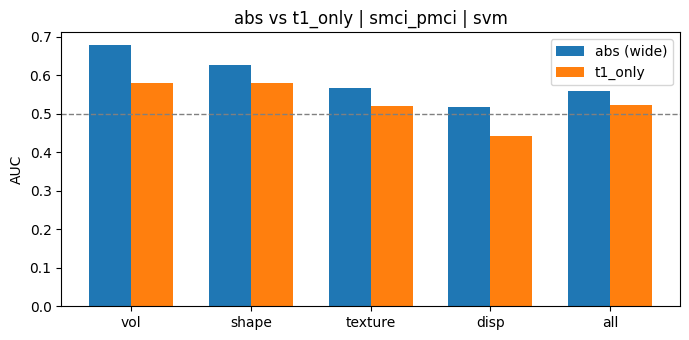

In [5]:
cfg = STATS_CFG

cmp_abs_t1 = compare_modalities(
    MODS_COMPARE,
    path_a=lambda m: image_ablation_path(BASE, "abs", m),
    path_b=lambda m: image_ablation_path(BASE, "t1_only", m),
    cfg_for_mod=lambda m: cfg_for_modality(m, cfg),
    load_patients=patient_scores_from_path,
    permutation_auc_p=permutation_auc_p,
    n_perm=cfg.n_perm,
    n_bootstrap=cfg.n_bootstrap,
    seed=cfg.seed,
    label_a="abs",
    label_b="t1_only",
    comparison="abs_vs_t1_only",
    alpha=ALPHA,
)
print(
    f"Comparação abs vs t1_only | {cfg.task} | {cfg.model_key} | "
    f"combat={cfg.with_combat} | {cfg.selection_mode}\n"
)
display(cmp_abs_t1.round(4))
print("\n── Interpretação (ΔAUC = abs − t1_only) ──")
print_comparison_summary(cmp_abs_t1, label_a="abs", label_b="t1_only")

if not cmp_abs_t1.empty:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    x = np.arange(len(cmp_abs_t1))
    w = 0.35
    ax.bar(x - w / 2, cmp_abs_t1["auc_abs"], w, label="abs (wide)")
    ax.bar(x + w / 2, cmp_abs_t1["auc_t1_only"], w, label="t1_only")
    ax.axhline(0.5, color="0.5", ls="--", lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(cmp_abs_t1["modality"])
    ax.set_ylabel("AUC")
    ax.set_title(f"abs vs t1_only | {cfg.task} | {cfg.model_key}")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. abs (leak-free) vs global (leaky)

**Pergunta:** o protocolo com vazamento (`global`) infla a AUC em relação ao `abs`?

- **ΔAUC** = AUC(abs) − AUC(global). Valores **negativos** → leaky parece melhor (inflação).
- Mesma config de modelo/seleção; FDR-BH sobre 5 modalidades.

**Para o paper:** quantificar se diferenças metodológicas alteram estimativa de performance de forma estatisticamente detectável.

In [6]:
cfg = STATS_CFG

cmp_abs_global = compare_modalities(
    MODS_COMPARE,
    path_a=lambda m: image_ablation_path(BASE, "abs", m),
    path_b=lambda m: image_ablation_path(BASE, "global", m),
    cfg_for_mod=lambda m: cfg_for_modality(m, cfg),
    load_patients=patient_scores_from_path,
    permutation_auc_p=permutation_auc_p,
    n_perm=cfg.n_perm,
    n_bootstrap=cfg.n_bootstrap,
    seed=cfg.seed + 100,
    label_a="abs",
    label_b="global",
    comparison="abs_vs_global",
    alpha=ALPHA,
)
print(f"abs vs global (leaky) | {cfg.task} | {cfg.model_key}\n")
display(cmp_abs_global.round(4))
print("\n── Interpretação (ΔAUC = abs − global; negativo → leaky maior) ──")
print_comparison_summary(cmp_abs_global, label_a="abs", label_b="global")

abs vs global (leaky) | smci_pmci | svm



,n_pacientes,auc_abs,auc_global,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,abs_superior,p_perm_abs,p_perm_global,significant_fdr,significant_raw,modality,comparison,p_fdr_bh
0,188,0.6780,0.6516,0.0264,-0.0370,0.0889,0.2132,0.4263,False,0.0002,0.0002,False,False,vol,abs_vs_global,0.9992
1,188,0.6262,0.6865,-0.0603,-0.1015,-0.0207,0.9976,0.0048,False,0.0032,0.0002,False,False,shape,abs_vs_global,0.9992
2,188,0.5681,0.7034,-0.1352,-0.2214,-0.0475,0.9992,0.0016,False,0.0516,0.0002,False,False,texture,abs_vs_global,0.9992
3,188,0.5187,0.5947,-0.0759,-0.1657,0.0150,0.9492,0.1016,False,0.3305,0.0136,False,False,disp,abs_vs_global,0.9992
4,188,0.5592,0.6880,-0.1288,-0.2193,-0.0380,0.9978,0.0044,False,0.0848,0.0002,False,False,all,abs_vs_global,0.9992



── Interpretação (ΔAUC = abs − global; negativo → leaky maior) ──
  vol: ΔAUC=0.026 [-0.037, 0.089]  p=0.2132  q=0.9992  → sem evidência
  shape: ΔAUC=-0.060 [-0.101, -0.021]  p=0.9976  q=0.9992  → sem evidência
  texture: ΔAUC=-0.135 [-0.221, -0.047]  p=0.9992  q=0.9992  → sem evidência
  disp: ΔAUC=-0.076 [-0.166, 0.015]  p=0.9492  q=0.9992  → sem evidência
  all: ΔAUC=-0.129 [-0.219, -0.038]  p=0.9978  q=0.9992  → sem evidência


## 6. Clínico vs imagem vs fusão (valor incremental)

Comparações na **modalidade principal** (`STATS_CFG.modality`, default `vol`):

| Comparação | ΔAUC | Interpretação |
|------------|------|----------------|
| **imagem (abs) − clínico** | > 0 | RM sozinha supera scores clínicos |
| **fusão − clínico** | > 0 | RM agrega além de MMSE/ADAS/FAQ |
| **fusão − imagem** | > 0 | Clínico agrega além da RM |

Fusão: `ablation_results_clinic_img/fusion_{mod}_l1_stable_nocombat_results_all.csv`  
Clínico: `ablation_results_clinic/clinical_results_all.csv`

> Use o **mesmo** `model_key` nos três (ex.: `svm` ou `elasticnet`).

Clínico / imagem / fusão | smci_pmci | mod=vol | svm



,n_pacientes,auc_img,auc_clin,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,img_superior,p_perm_img,p_perm_clin,significant_fdr,significant_raw,modality,comparison,auc_fusion,fusion_superior,p_perm_fusion,p_fdr_bh
0,188,0.678,0.7606,-0.0826,-0.1850,0.0184,0.9436,0.1128,False,0.0002,0.0002,False,False,vol,image_abs_vs_clinical,NaN,NaN,NaN,0.9436
1,188,NaN,0.7606,-0.0218,-0.0781,0.0362,0.7754,0.4491,NaN,NaN,0.0002,False,False,vol,fusion_vs_clinical,0.7388,False,0.0002,0.9436
2,188,0.678,NaN,0.0608,-0.0025,0.1232,0.0294,0.0588,NaN,0.0002,NaN,False,False,vol,fusion_vs_image_abs,0.7388,False,0.0002,0.0882



── Interpretação ──
  image_abs_vs_clinical: ΔAUC=-0.083 [-0.185, 0.018]  p=0.9436
  fusion_vs_clinical: ΔAUC=-0.022 [-0.078, 0.036]  p=0.7754
  fusion_vs_image_abs: ΔAUC=0.061 [-0.002, 0.123]  p=0.0294


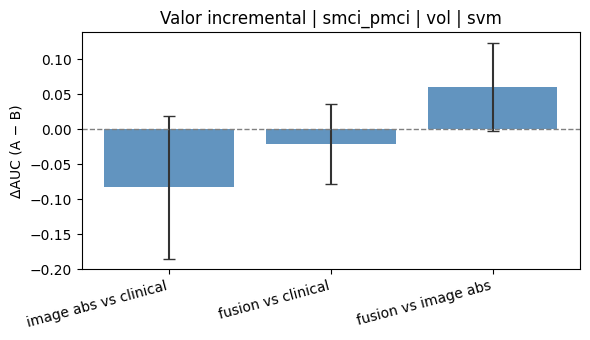

In [7]:
cfg = STATS_CFG
mod = cfg.modality
img_cfg = cfg_for_modality(mod, cfg)
clin_cfg = cfg_clinical(cfg)
fusion_path = fusion_results_path(
    BASE, mod, selection_mode=cfg.selection_mode, with_combat=cfg.with_combat,
)
clin_path = clinical_results_path(BASE)
img_path = image_ablation_path(BASE, "abs", mod)

clinical_rows: list[dict] = []
if img_path.exists() and clin_path.exists():
    paired = patient_scores_from_path(img_path, img_cfg).merge(
        patient_scores_from_path(clin_path, clin_cfg),
        on=["ID_PT", "y"],
        suffixes=("_img", "_clin"),
    )
    row = paired_comparison_row(
        paired,
        score_a="score_img",
        score_b="score_clin",
        label_a="img",
        label_b="clin",
        n_boot=cfg.n_bootstrap,
        seed=cfg.seed + 200,
        permutation_auc_p=permutation_auc_p,
        n_perm=cfg.n_perm,
        alpha=ALPHA,
    )
    row.update({"modality": mod, "comparison": "image_abs_vs_clinical"})
    clinical_rows.append(row)

if fusion_path.exists() and clin_path.exists():
    paired = patient_scores_from_path(fusion_path, img_cfg).merge(
        patient_scores_from_path(clin_path, clin_cfg),
        on=["ID_PT", "y"],
        suffixes=("_fusion", "_clin"),
    )
    row = paired_comparison_row(
        paired,
        score_a="score_fusion",
        score_b="score_clin",
        label_a="fusion",
        label_b="clin",
        n_boot=cfg.n_bootstrap,
        seed=cfg.seed + 201,
        permutation_auc_p=permutation_auc_p,
        n_perm=cfg.n_perm,
        alpha=ALPHA,
    )
    row.update({"modality": mod, "comparison": "fusion_vs_clinical"})
    clinical_rows.append(row)

if fusion_path.exists() and img_path.exists():
    paired = patient_scores_from_path(fusion_path, img_cfg).merge(
        patient_scores_from_path(img_path, img_cfg),
        on=["ID_PT", "y"],
        suffixes=("_fusion", "_img"),
    )
    row = paired_comparison_row(
        paired,
        score_a="score_fusion",
        score_b="score_img",
        label_a="fusion",
        label_b="img",
        n_boot=cfg.n_bootstrap,
        seed=cfg.seed + 202,
        permutation_auc_p=permutation_auc_p,
        n_perm=cfg.n_perm,
        alpha=ALPHA,
    )
    row.update({"modality": mod, "comparison": "fusion_vs_image_abs"})
    clinical_rows.append(row)

cmp_clinical = pd.DataFrame(clinical_rows)
if not cmp_clinical.empty:
    cmp_clinical["p_fdr_bh"] = apply_bh_fdr(cmp_clinical["p_bootstrap_one_sided"].to_numpy())
    cmp_clinical["significant_fdr"] = (
        cmp_clinical["p_fdr_bh"] < ALPHA
    ) & (cmp_clinical["ci95_lo"] > 0)

print(f"Clínico / imagem / fusão | {cfg.task} | mod={mod} | {cfg.model_key}\n")
display(cmp_clinical.round(4))

print("\n── Interpretação ──")
for _, r in cmp_clinical.iterrows():
    print(
        f"  {r['comparison']}: ΔAUC={r['delta_auc']:.3f} "
        f"[{r['ci95_lo']:.3f}, {r['ci95_hi']:.3f}]  p={r['p_bootstrap_one_sided']:.4f}"
    )

if not cmp_clinical.empty:
    fig, ax = plt.subplots(figsize=(6, 3.5))
    labels = cmp_clinical["comparison"].str.replace("_", " ", regex=False)
    x = np.arange(len(cmp_clinical))
    ax.bar(x, cmp_clinical["delta_auc"], color="steelblue", alpha=0.85)
    ax.errorbar(
        x,
        cmp_clinical["delta_auc"],
        yerr=[
            cmp_clinical["delta_auc"] - cmp_clinical["ci95_lo"],
            cmp_clinical["ci95_hi"] - cmp_clinical["delta_auc"],
        ],
        fmt="none",
        color="0.2",
        capsize=4,
    )
    ax.axhline(0, color="0.5", ls="--", lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_ylabel("ΔAUC (A − B)")
    ax.set_title(f"Valor incremental | {cfg.task} | {mod} | {cfg.model_key}")
    plt.tight_layout()
    plt.show()

## 7. Atributos mais selecionados (estabilidade)

Frequência de cada biomarcador nos folds externos (`selected_features`), agrupando T1/T2/T3.

- **coverage**: % folds em que o atributo entrou na seleção final
- **pct_T1/T2/T3**: em quais visitas aparece (protocolo `abs`)

Comparar **abs** vs **t1_only** na modalidade principal sustenta narrativa longitudinal.

In [8]:
cfg = STATS_CFG
mod = cfg.modality
feat_cfg = cfg_for_modality(mod, cfg)

feat_tables: dict[str, pd.DataFrame] = {}
for proto, label in (("abs", "abs_wide"), ("t1_only", "t1_only")):
    path = image_ablation_path(BASE, proto, mod)
    if not path.exists():
        print(f"skip {proto}: {path}")
        continue
    raw = prepare_ablation_df(pd.read_csv(path))
    mask = (
        (raw["task"] == feat_cfg.task)
        & (raw["modality"] == mod)
        & (raw["model_key"] == feat_cfg.model_key)
        & (raw["with_combat"] == feat_cfg.with_combat)
        & (raw["selection_mode"] == feat_cfg.selection_mode)
    )
    sub = raw.loc[mask]
    if sub.empty:
        print(f"sem linhas para {proto} / {mod}")
        continue
    grp = feature_freq_table_grouped(sub, min_coverage=FEATURE_MIN_COVERAGE / 100)
    grp.insert(0, "protocol", label)
    feat_tables[label] = grp
    print(f"\n── Top atributos ({label}) | coverage ≥ {FEATURE_MIN_COVERAGE}% ──")
    show_cols = [
        "feature_short", "coverage_pct", "pct_T1", "pct_T2", "pct_T3", "amplitude",
    ]
    display(grp.head(15)[[c for c in show_cols if c in grp.columns]])

if "abs_wide" in feat_tables and "t1_only" in feat_tables:
    merge = feat_tables["abs_wide"].merge(
        feat_tables["t1_only"][["feature_group", "coverage_pct"]],
        on="feature_group",
        how="outer",
        suffixes=("_abs", "_t1"),
    ).sort_values("coverage_pct_abs", ascending=False, na_position="last")
    print("\n── Cobertura abs vs t1_only (mesmo biomarcador anatômico) ──")
    display(merge.head(15))


── Top atributos (abs_wide) | coverage ≥ 50% ──


,feature_short,coverage_pct,pct_T1,pct_T2,pct_T3,amplitude
0,L | csf_norm,100,100,100,100,1.000000
1,L | gm_norm,100,100,100,100,1.000000
2,R | csf_norm,100,100,100,100,1.000000
3,R | gm_norm,100,100,100,100,1.000000
4,L | wm_norm,100,96,100,88,0.946667
5,R | wm_norm,100,16,100,24,0.466667



── Top atributos (t1_only) | coverage ≥ 50% ──


,feature_short,coverage_pct,pct_T1,pct_T2,pct_T3,amplitude
0,L | csf_norm,100,100,0,0,0.333333
1,L | gm_norm,100,100,0,0,0.333333
2,R | csf_norm,100,100,0,0,0.333333
3,R | gm_norm,100,100,0,0,0.333333
4,L | wm_norm,88,88,0,0,0.333333



── Cobertura abs vs t1_only (mesmo biomarcador anatômico) ──


,protocol,task,modality,combat_label,model_key,selection_mode,feature_group,feature_short,coverage,coverage_pct_abs,...,n_folds_any,total_selections,n_runs,freq_T1,pct_T1,freq_T2,pct_T2,freq_T3,pct_T3,coverage_pct_t1
0,abs_wide,smci_pmci,vol,sem ComBat,svm,l1_stable,hippocampus_L_csf_norm,L | csf_norm,1.0,100,...,25,75,25,1.00,100,1.0,100,1.00,100,100.0
1,abs_wide,smci_pmci,vol,sem ComBat,svm,l1_stable,hippocampus_L_gm_norm,L | gm_norm,1.0,100,...,25,75,25,1.00,100,1.0,100,1.00,100,100.0
2,abs_wide,smci_pmci,vol,sem ComBat,svm,l1_stable,hippocampus_L_wm_norm,L | wm_norm,1.0,100,...,25,71,25,0.96,96,1.0,100,0.88,88,88.0
3,abs_wide,smci_pmci,vol,sem ComBat,svm,l1_stable,hippocampus_R_csf_norm,R | csf_norm,1.0,100,...,25,75,25,1.00,100,1.0,100,1.00,100,100.0
4,abs_wide,smci_pmci,vol,sem ComBat,svm,l1_stable,hippocampus_R_gm_norm,R | gm_norm,1.0,100,...,25,75,25,1.00,100,1.0,100,1.00,100,100.0
5,abs_wide,smci_pmci,vol,sem ComBat,svm,l1_stable,hippocampus_R_wm_norm,R | wm_norm,1.0,100,...,25,35,25,0.16,16,1.0,100,0.24,24,NaN


## 8. Exportar CSV

| Arquivo | Conteúdo |
|---------|----------|
| `stats_{task}_{modality}.csv` | Secções 1–2 (demografia + modelos) |
| `stats_abs_vs_t1only_{task}_{model}.csv` | Secção 4 |
| `stats_abs_vs_global_{task}_{model}.csv` | Secção 5 |
| `stats_clinical_{task}_{model}.csv` | Secção 6 |
| `stats_features_{task}_{mod}_{model}.csv` | Secção 7 (abs wide) |
| `stats_comparisons_all_{task}_{model}.csv` | Tabela mestre (4+5+6) |

In [ ]:
cfg = STATS_CFG

out = summary.copy()
out.insert(0, "task", cfg.task)
out.insert(1, "modality", cfg.modality)
out.insert(2, "model_key", cfg.model_key)
out.insert(3, "protocol", cfg.protocol)
out.insert(4, "with_combat", cfg.with_combat)
out.insert(5, "selection_mode", cfg.selection_mode)

out_path = BASE / f"stats_{cfg.task}_{cfg.modality}.csv"
out.to_csv(out_path, index=False)
print(f"Salvo: {out_path}")

def _export_cmp(df: pd.DataFrame, fname: str) -> None:
    if df is None or df.empty:
        print(f"skip {fname} (vazio)")
        return
    out_df = df.copy()
    for col, val in (
        ("task", cfg.task),
        ("model_key", cfg.model_key),
        ("with_combat", cfg.with_combat),
        ("selection_mode", cfg.selection_mode),
    ):
        if col not in out_df.columns:
            out_df.insert(0, col, val)
    path = BASE / fname
    out_df.to_csv(path, index=False)
    print(f"Salvo: {path}")

_export_cmp(cmp_abs_t1, f"stats_abs_vs_t1only_{cfg.task}_{cfg.model_key}.csv")
_export_cmp(cmp_abs_global, f"stats_abs_vs_global_{cfg.task}_{cfg.model_key}.csv")
_export_cmp(cmp_clinical, f"stats_clinical_{cfg.task}_{cfg.model_key}.csv")

if "abs_wide" in feat_tables:
    feat_path = BASE / f"stats_features_{cfg.task}_{cfg.modality}_{cfg.model_key}.csv"
    feat_tables["abs_wide"].to_csv(feat_path, index=False)
    print(f"Salvo: {feat_path}")

master_parts = [d for d in (cmp_abs_t1, cmp_abs_global, cmp_clinical) if d is not None and not d.empty]
if master_parts:
    master = pd.concat(master_parts, ignore_index=True, sort=False)
    master_path = BASE / f"stats_comparisons_all_{cfg.task}_{cfg.model_key}.csv"
    master.to_csv(master_path, index=False)
    print(f"Salvo: {master_path}")
    display(master.round(4))


Salvo: csvs/longitudinal_4_groups/stats_smci_pmci_vol.csv


,task,modality,protocol,modelo,features,auc,p_permutation,ci95,confunde,imagem_superior,p_idade_entre_grupos,p_sexo_entre_grupos
0,smci_pmci,vol,abs,só idade,AGE,0.4555,0.8546,,False,NaN,0.5664,0.5618
1,smci_pmci,vol,abs,só sexo,SEX_bin,0.5067,0.4277,,False,NaN,0.5664,0.5618
2,smci_pmci,vol,abs,imagem (abs),vol,0.6787,0.0002,,False,NaN,0.5664,0.5618
3,smci_pmci,vol,abs,imagem − idade,ΔAUC,0.2232,NaN,"[0.102, 0.341]",NaN,True,0.5664,0.5618
4,smci_pmci,vol,abs,imagem − sexo,ΔAUC,0.1720,NaN,"[0.047, 0.297]",NaN,True,0.5664,0.5618
